# Data_Analysis_Notebook

Here we consider recordings of action potentials and extracellular local field potential (LFP) obtained from the primary somatosensory cortex from the rat. Tactile stimulations were applied on the tip of the forehand digit (2, 3, 4 and 5) while extracellular recording electrodes were placed in layer 4 of the Forehand representation of the primary somatosensory cortex.

Each file contains the data for 900 stimuli, with the following variables:
- DataUnit: dictionary of all variables
- LFP: analog local-field potential signal Sampling rate = 1000 Hz
- Unit: list of 0 or 1 (1 corresponding to a spike) for all time points Sampling rate = 1000 Hz
- SpikeTiming: list of spike times 
- StimCond: array with column 0 containing the time stamp for each stimulus, and column 1 the stimulus type 

    (**note that the stimulus is applied 50ms after that time stamp**)
- WaveForm: waveform of the recorded spike

The aim of this notebook is to learn how to analyse electrophysiological data, performing some basic analyses and visualizations.


In [186]:
import numpy as np
import matplotlib.pyplot as plt
import os   

# if last word in path == scripts then go back one directory
if os.getcwd().endswith('scripts'):
    os.chdir('..')
os.getcwd()


'd:\\DATA\\Projets\\EMN_IntroProgram_NC'

In [187]:

# data is a dictionary with keys: 'LFP', 'Unit', 'StimCond'
# here, we load the data from a .npy file and extract the relevant components for analysis.
data = np.load("data/Cell_4.npy", allow_pickle=True)
data = data.item()
lfp=data['LFP']
unit=data['Unit']
StimCond=data['StimCond']
data.keys()
StimCond


array([[   2117,       5],
       [   3225,       5],
       [   4337,       2],
       ...,
       [ 998321,       2],
       [ 999429,       3],
       [1000534,       3]], shape=(900, 2), dtype=int32)

# *LFP  (local field potential)*

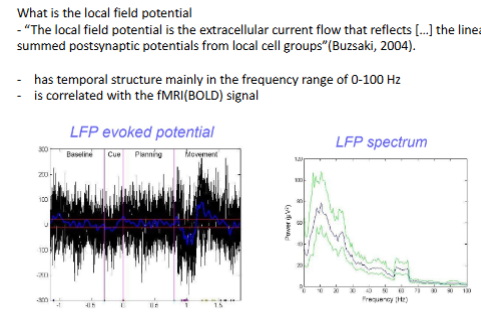

For today : 
- realigning LFP on stimulus onsets
- Raster plot
- PSTH
- tuning curves


array([5, 5, 2, 2, 3, 2, 3, 4, 3, 2, 3, 2, 5, 2, 2, 2, 5, 3, 5, 5, 2, 5,
       2, 4, 3, 3, 2, 3, 2, 3, 4, 4, 2, 5, 3, 3, 4, 4, 4, 5, 3, 5, 4, 2,
       3, 5, 2, 5, 4, 2, 4, 4, 5, 3, 3, 2, 3, 2, 2, 4, 4, 2, 3, 5, 5, 3,
       2, 5, 4, 2, 5, 4, 4, 2, 3, 2, 3, 3, 3, 2, 2, 3, 2, 5, 5, 5, 4, 3,
       2, 3, 3, 3, 2, 3, 5, 3, 4, 2, 3, 4, 4, 4, 2, 3, 5, 4, 5, 2, 5, 2,
       2, 3, 2, 4, 4, 4, 3, 2, 4, 4, 3, 2, 3, 3, 3, 3, 2, 4, 5, 4, 2, 5,
       5, 3, 5, 4, 5, 2, 2, 2, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 5, 4, 4, 2,
       2, 3, 5, 5, 5, 2, 4, 3, 4, 4, 3, 2, 2, 3, 4, 5, 4, 2, 2, 2, 4, 2,
       2, 3, 5, 4, 2, 5, 4, 3, 2, 5, 4, 2, 2, 2, 3, 4, 2, 2, 2, 5, 2, 5,
       2, 2, 2, 4, 5, 5, 3, 3, 4, 5, 2, 4, 3, 4, 3, 3, 3, 5, 2, 3, 2, 3,
       5, 2, 2, 2, 4, 5, 4, 3, 4, 2, 3, 3, 2, 5, 5, 2, 4, 5, 5, 5, 4, 3,
       3, 2, 2, 3, 5, 4, 3, 3, 5, 2, 4, 3, 2, 3, 4, 4, 3, 4, 4, 2, 4, 3,
       5, 3, 3, 2, 3, 5, 2, 4, 4, 5, 3, 5, 2, 3, 2, 2, 2, 3, 4, 3, 5, 4,
       3, 2, 4, 4, 2, 2, 4, 2, 3, 4, 4, 2, 4, 5, 2,

In [189]:
np.where(StimCond[:,1]==5)

(array([  0,   1,  12,  16,  18,  19,  21,  33,  39,  41,  45,  47,  52,
         63,  64,  67,  70,  83,  84,  85,  94, 104, 106, 108, 128, 131,
        132, 134, 136, 150, 156, 157, 158, 169, 178, 181, 185, 195, 197,
        202, 203, 207, 215, 220, 225, 233, 234, 237, 238, 239, 246, 250,
        264, 269, 273, 275, 284, 299, 304, 322, 332, 333, 336, 349, 358,
        366, 392, 397, 400, 409, 419, 445, 451, 460, 462, 465, 466, 473,
        474, 476, 482, 487, 490, 508, 520, 522, 532, 534, 539, 543, 547,
        549, 553, 558, 573, 585, 587, 589, 591, 603, 605, 607, 612, 614,
        629, 632, 636, 638, 641, 646, 649, 660, 661, 667, 671, 672, 675,
        681, 694, 697, 701, 704, 709, 712, 718, 720, 725, 731, 733, 734,
        736, 738, 758, 763, 773, 774, 780, 782, 820, 822, 826, 830, 834,
        848, 851, 855, 859, 862, 877, 880]),)

In [190]:
# here we realign the LFP data to the stimulus onset, which is indicated by the StimCond array. We extract a window of LFP data around each stimulus onset and store it in a list for further analysis.
lfp_aligned=[]

for i in range(len(StimCond)):
   stim_onset=StimCond[i,0]+50
   lfp_aligned.append(lfp[stim_onset-50:stim_onset+100])

lfp_aligned=np.array(lfp_aligned)


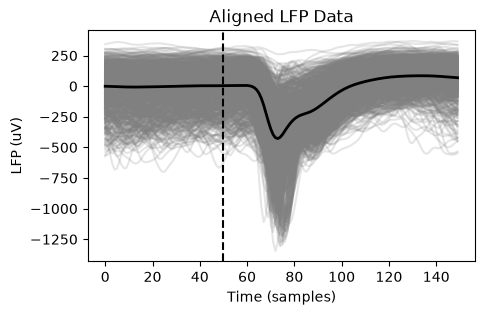

In [191]:

plt.figure(figsize=(5,3))
plt.plot(lfp_aligned.T,'gray' ,alpha=0.2)
plt.plot(np.mean(lfp_aligned,axis=0),'k',linewidth=2)
plt.axvline(x=50,color='k',linestyle='--')
plt.xlabel('Time (samples)')
plt.ylabel('LFP (uV)')
plt.title('Aligned LFP Data')
plt.show()



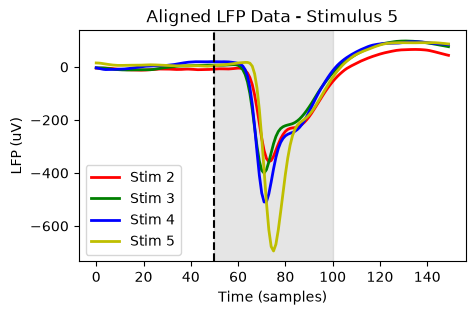

In [204]:

plt.figure(figsize=(5,3))
color=['r','g','b','y']

for stim in [2,3,4,5]:

    plt.plot(np.mean(lfp_aligned[StimCond[:,1]==stim,:],axis=0),linewidth=2,color=color[stim-2])
    plt.xlabel('Time (samples)')
    plt.ylabel('LFP (uV)')
    plt.title(f'Aligned LFP Data - Stimulus {stim}')
    
    
plt.axvline(x=50,color='k',linestyle='--')
plt.axvspan(50, 100, color='gray', alpha=0.2)
plt.legend(['Stim 2','Stim 3','Stim 4','Stim 5'])
plt.show()






In [193]:
import seaborn as sns


F-statistic: 67.87, p-value: 0.0000000000


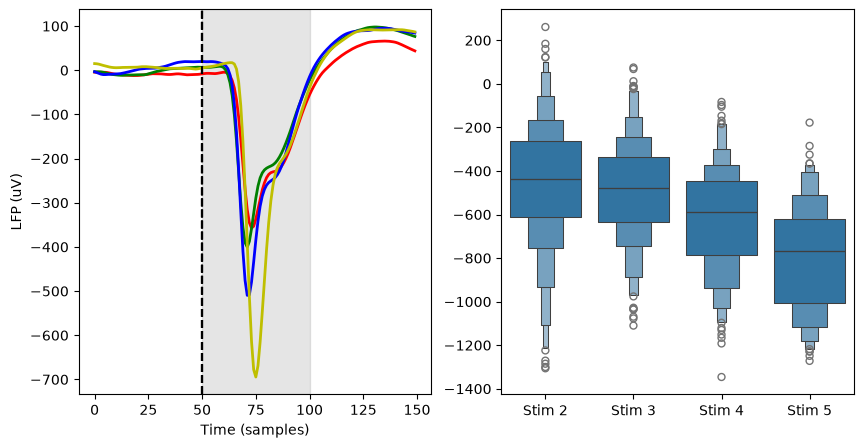

In [209]:

fig,ax=plt.subplots(1,2,figsize=(10,5))

color=['r','g','b','y']

for stim in [2,3,4,5]:
    ax[0].plot(np.mean(lfp_aligned[StimCond[:,1]==stim,:],axis=0),linewidth=2,color=color[stim-2])
    ax[0].axvline(x=50,color='k',linestyle='--')
    ax[0].set_xlabel('Time (samples)')
    ax[0].set_ylabel('LFP (uV)')
    
ax[0].axvspan(50, 100, color='gray', alpha=0.2)
    
Var_to_test=np.min(lfp_aligned[:,50:100],axis=1)

sns.boxenplot(x=StimCond[:,1],y=Var_to_test,ax=ax[1])
ax[1].set_xticks([0,1,2,3])
ax[1].set_xticklabels(['Stim 2','Stim 3','Stim 4','Stim 5'])

import scipy.stats as stats

# Perform a one-way ANOVA to compare the means of the different stimulus conditions
f_stat, p_value = stats.f_oneway(
    Var_to_test[StimCond[:,1]==2],
    Var_to_test[StimCond[:,1]==3],
    Var_to_test[StimCond[:,1]==4],
    Var_to_test[StimCond[:,1]==5]
)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.10f}")

# *Single Unit (SU)*
Single Unit (SU) data is a binary array where 1 indicates a spike and 0 indicates no spike. We can realign the SU data to the stimulus onset in a similar way as we did for the LFP data, and then plot the aligned SU data as a raster plot.

In [195]:
len(unit)  

# here we realign the LFP data to the stimulus onset, which is indicated by the StimCond array. We extract a window of LFP data around each stimulus onset and store it in a list for further analysis.
unit_aligned=[]

for i in range(len(StimCond)):
   stim_onset=StimCond[i,0]+50
   unit_aligned.append(unit[stim_onset-50:stim_onset+100])

unit_aligned=np.array(unit_aligned)


In [196]:
unit_aligned.shape

(900, 150)

# Raster plot

A raster plot in neuroscience is a graphical chart that shows when individual neurons fire action potentials (spikes) over time.

Key Components

• X-axis: Represents time (e.g., seconds or milliseconds).
• Y-axis: Represents different neurons (or different trials of the same neuron).
• Markers: Each vertical tick mark, dot, or line corresponds to a single spike emitted at that exact moment

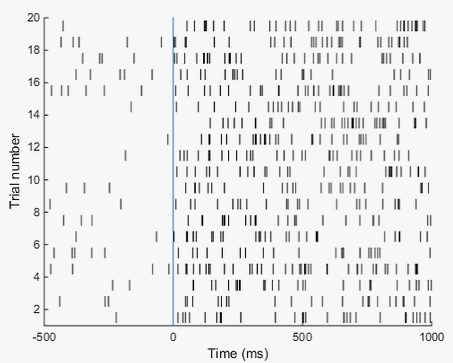

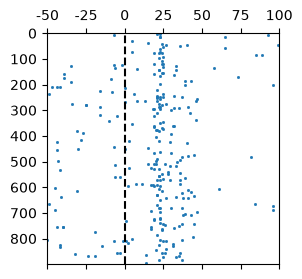

In [201]:
plt.figure(figsize=(3,3))

plt.spy(unit_aligned[:,:],aspect='auto',markersize=1)
plt.axvline(x=50,color='k',linestyle='--')
plt.xticks([0,25,50,75,100,125,150],np.array([-50,-25,0,25,50,75,100]))
plt.show()


# PSTH
In neurophysiology, peristimulus time histogram and poststimulus time histogram, both abbreviated PSTH or PST histogram, are histograms of the times at which neurons fire. It is also sometimes called pre event time histogram or PETH. These histograms are used to visualize the rate and timing of neuronal spike discharges in relation to an external stimulus or event. The peristimulus time histogram is sometimes called perievent time histogram

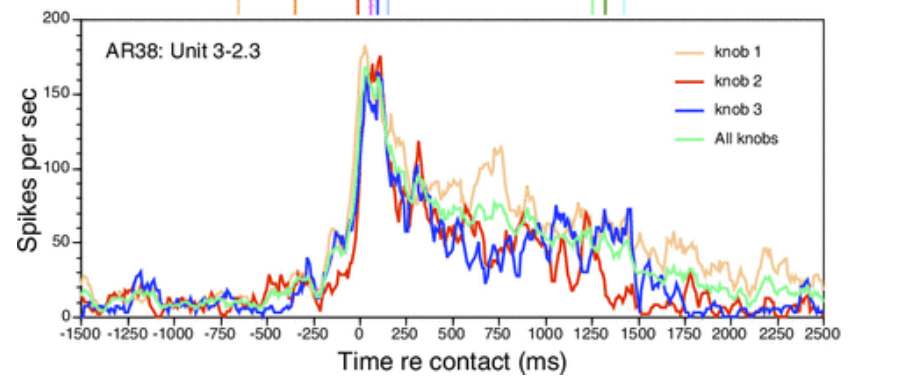



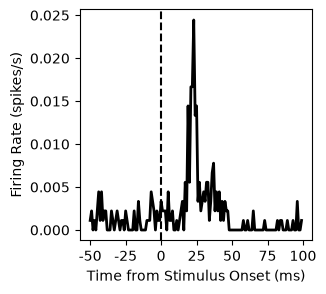

In [198]:
plt.figure(figsize=(3,3))
plt.plot(np.mean(unit_aligned,axis=0),'k',linewidth=2)
plt.axvline(x=50,color='k',linestyle='--')
plt.xticks([0,25,50,75,100,125,150],np.array([-50,-25,0,25,50,75,100]))
plt.xlabel('Time from Stimulus Onset (ms)')
plt.ylabel('Firing Rate (spikes/s)')
plt.show()


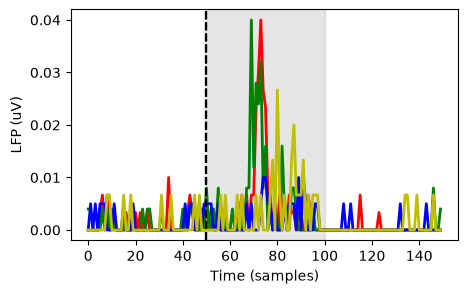

In [199]:
fig,ax=plt.subplots(1,1,figsize=(5,3))

color=['r','g','b','y']

for stim in [2,3,4,5]:
    ax.plot(np.mean(unit_aligned[StimCond[:,1]==stim,:],axis=0),linewidth=2,color=color[stim-2])
    ax.axvline(x=50,color='k',linestyle='--')
    ax.set_xlabel('Time (samples)')
    ax.set_ylabel('LFP (uV)')
    # ax.set_xticks([0,25,50,75,100,125,150],np.array([-50,-25,0,25,50,75,100]))
ax.axvspan(50, 100, color='gray', alpha=0.2)

# Tuning curve

A neuron tuning curve is a graph that shows how a neuron's activity (measured by its firing rate or action potentials per second) changes in response to a specific, continuous stimulus or task variable

X-axis (Stimulus Parameter): Represents a feature like sound frequency, light orientation, color wavelength, movement direction, or spatial position.

Y-axis (Neural Activity): Represents the response strength, usually expressed as spikes per second (firing rate).

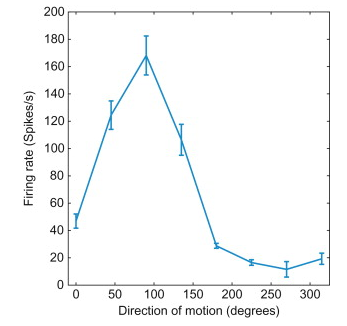

Text(0, 0.5, 'Mean Firing Rate (spikes/s)')

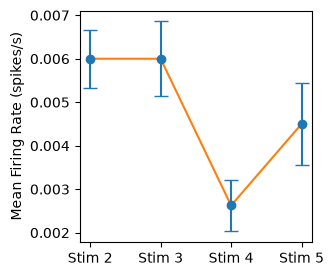

In [200]:
Var_to_test=np.mean(unit_aligned[:,60:100],axis=1)

fig,ax=plt.subplots(1,1,figsize=(3,3))
plt.errorbar(x=[0,1,2,3], y=[np.mean(Var_to_test[StimCond[:,1]==stim]) for stim in [2,3,4,5]],
             yerr=[np.std(Var_to_test[StimCond[:,1]==stim])/np.sqrt(np.sum(StimCond[:,1]==stim)) for stim in [2,3,4,5]],
             fmt='o', capsize=5)
plt.plot([np.mean(Var_to_test[StimCond[:,1]==stim]) for stim in [2,3,4,5]])
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['Stim 2','Stim 3','Stim 4','Stim 5'])
ax.set_ylabel('Mean Firing Rate (spikes/s)')